# 🛍️ Mall Customer Segmentation with K-Means

**Goal:** group mall customers into meaningful segments based on their income and spending behaviour, so the marketing team can treat each group differently.

**Dataset:** `Mall_Customers.csv` — 200 customers (`Gender`, `Age`, `Annual Income (k$)`, `Spending Score (1-100)`).

**Workflow**
1. Load & inspect the data
2. Exploratory data analysis (EDA)
3. Preprocessing (feature selection, scaling)
4. Choosing the number of clusters (elbow + silhouette)
5. Fitting K-Means & validating the result
6. Profiling and naming the segments
7. Saving the model and predicting new customers

## 1- Setup 

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import joblib 

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score, adjusted_rand_score


SEED= 42 
sns.set_theme(style='whitegrid',context='notebook')
plt.rcParams['figure.dpi']=110

GENDER_COLORS= {'Female': '#E377C2' , 'Male':'#1F77B4'}

## 2- Load & Inspect the Data 

In [2]:
df= pd.read_csv('Mall_Customers.csv')
df = df.rename(columns={'Annual Income (k$)': 'Income', 'Spending Score (1-100)': 'Spending'})
df.head()

,CustomerID,Gender,Age,Income,Spending
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
print('Shape:', df.shape)
print('\nMissing values per column:')
print(df.isna().sum())
print('\nDuplicated rows:', df.duplicated().sum())
print('Duplicated CustomerIDs:', df['CustomerID'].duplicated().sum())
print()
df.info()

Shape: (200, 5)

Missing values per column:
CustomerID    0
Gender        0
Age           0
Income        0
Spending      0
dtype: int64

Duplicated rows: 0
Duplicated CustomerIDs: 0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   CustomerID  200 non-null    int64 
 1   Gender      200 non-null    object
 2   Age         200 non-null    int64 
 3   Income      200 non-null    int64 
 4   Spending    200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [4]:
df[['Age', 'Income', 'Spending']].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Age,200.0,38.85,13.97,18.0,28.75,36.0,49.0,70.0
Income,200.0,60.56,26.26,15.0,41.50,61.5,78.0,137.0
Spending,200.0,50.20,25.82,1.0,34.75,50.0,73.0,99.0


**Takeaways**
- 200 rows, no missing values, no duplicates → no imputation or de-duplication is needed.
- `CustomerID` is just an identifier, so it must **not** be used as a feature.
- Ages range from 18 to 70, income from 15k$ to 137k$, and the spending score covers almost the whole 1–100 scale.

## 3- EDA (Data Visualization)

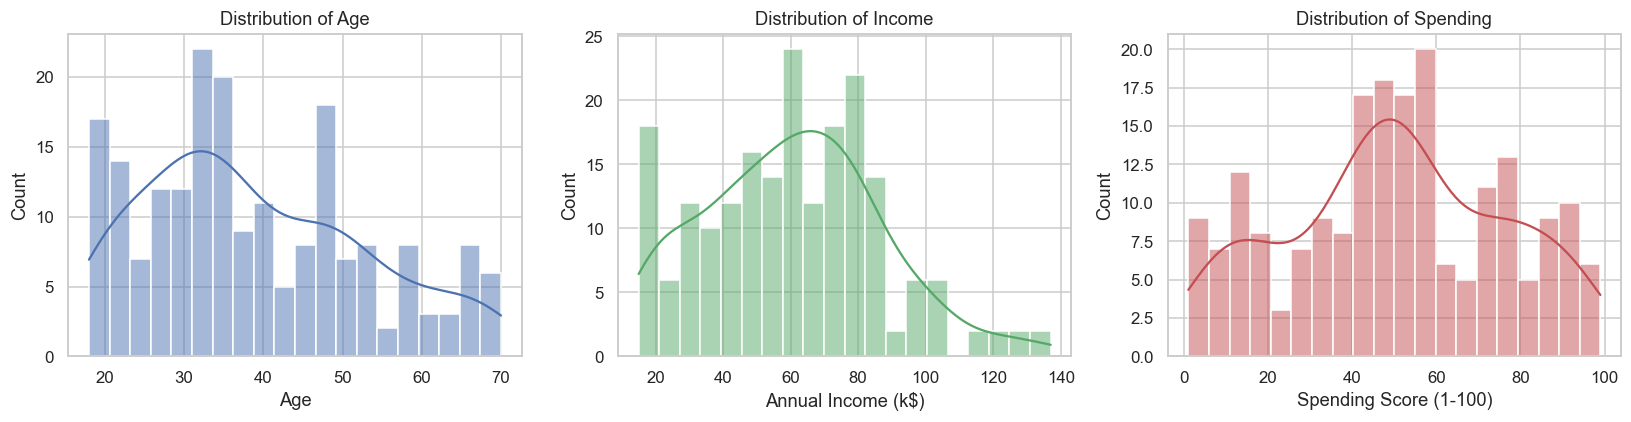

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, color in zip(axes, ['Age', 'Income', 'Spending'], ['#4C72B0', '#55A868', '#C44E52']):
    sns.histplot(df[col], kde=True, bins=20, color=color, ax=ax)
    ax.set_title(f'Distribution of {col}')
axes[1].set_xlabel('Annual Income (k$)')
axes[2].set_xlabel('Spending Score (1-100)')
plt.tight_layout()
plt.show()

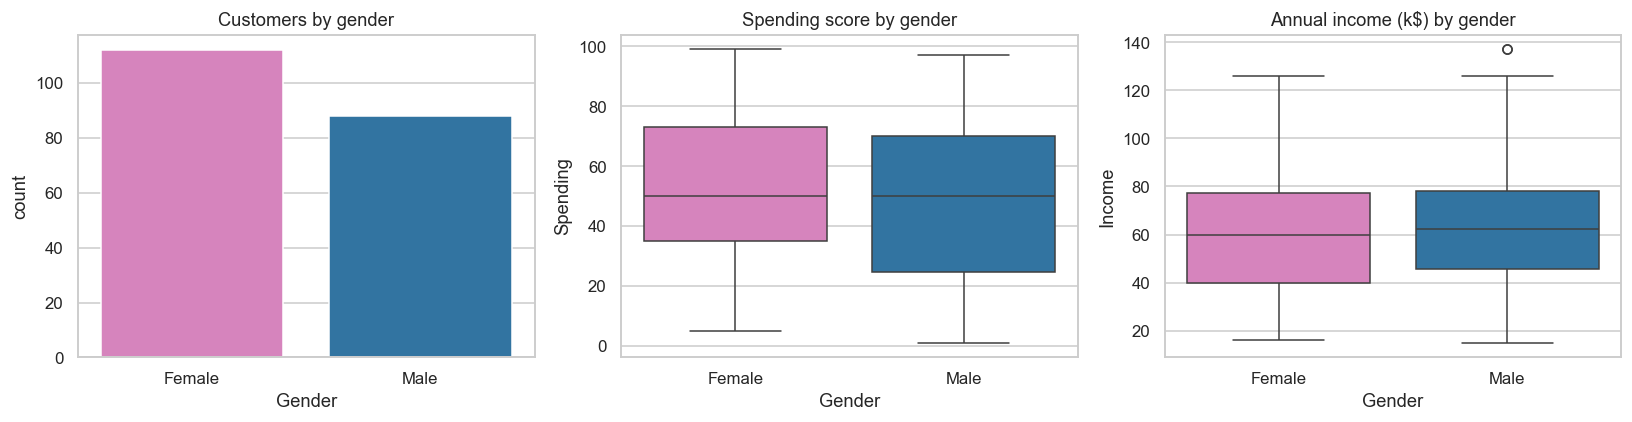

Age        Income        Spending       
        mean median   mean median     mean median
Gender                                           
Female  38.1   35.0   59.2   60.0     51.5   50.0
Male    39.8   37.0   62.2   62.5     48.5   50.0

In [6]:
order = ['Female', 'Male']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.countplot(data=df, x='Gender', order=order, hue='Gender', palette=GENDER_COLORS, legend=False, ax=axes[0])
axes[0].set_title('Customers by gender')

sns.boxplot(data=df, x='Gender', y='Spending', order=order, hue='Gender', palette=GENDER_COLORS, legend=False, ax=axes[1])
axes[1].set_title('Spending score by gender')

sns.boxplot(data=df, x='Gender', y='Income', order=order, hue='Gender', palette=GENDER_COLORS, legend=False, ax=axes[2])
axes[2].set_title('Annual income (k$) by gender')

plt.tight_layout()
plt.show()

df.groupby('Gender')[['Age', 'Income', 'Spending']].agg(['mean', 'median']).round(1)

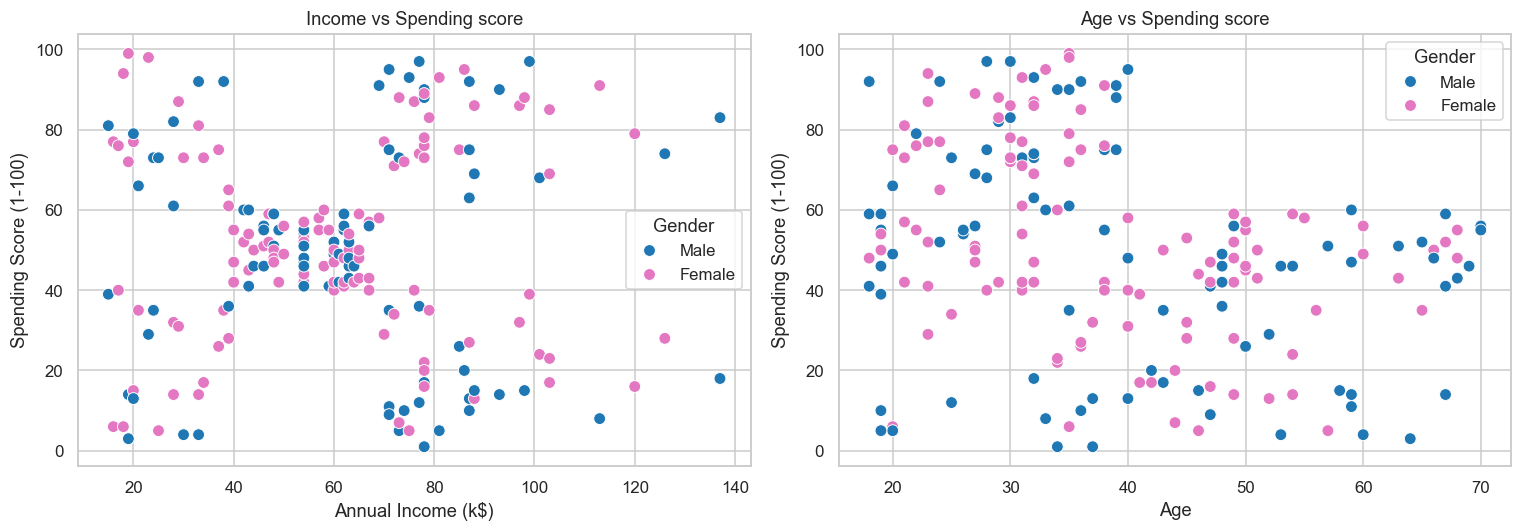

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x='Income', y='Spending', hue='Gender', palette=GENDER_COLORS, s=60, ax=axes[0])
axes[0].set_title('Income vs Spending score')
axes[0].set_xlabel('Annual Income (k$)')
axes[0].set_ylabel('Spending Score (1-100)')

sns.scatterplot(data=df, x='Age', y='Spending', hue='Gender', palette=GENDER_COLORS, s=60, ax=axes[1])
axes[1].set_title('Age vs Spending score')
axes[1].set_ylabel('Spending Score (1-100)')

plt.tight_layout()
plt.show()

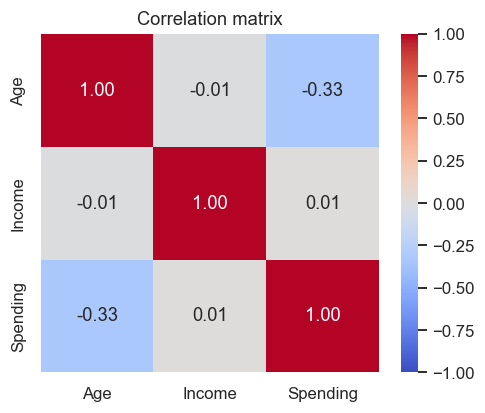

In [8]:
corr = df[['Age', 'Income', 'Spending']].corr()

plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Correlation matrix')
plt.show()

**What the EDA tells us**
- Gender counts are slightly imbalanced (more women) but spending and income are very similar for both genders → **gender is unlikely to drive the segments**.
- Income and spending are essentially **uncorrelated** (≈ 0), so a single linear trend can't describe them. But the scatter plot clearly shows **separate blocks of customers** → a natural clustering problem.
- Age has a mild **negative** correlation with spending: younger customers tend to score higher.

## 4. Preprocessing

### 4.1 Outlier check (Income)
We only *inspect* outliers here — we don't change the data unless there is a reason to.

In [9]:
q1, q3 = df['Income'].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr

outliers = df[(df['Income'] < lower) | (df['Income'] > upper)]
print(f'IQR fences for Income: [{lower:.2f}, {upper:.2f}]')
print(f'Rows outside the fences: {len(outliers)} of {len(df)}')
outliers

IQR fences for Income: [-13.25, 132.75]
Rows outside the fences: 2 of 200


,CustomerID,Gender,Age,Income,Spending
198,199,Male,32,137,18
199,200,Male,30,137,83


Only two customers fall above the fence, both at 137k$. They are real, plausible high earners (not data errors), and they are exactly the kind of customers a segmentation should capture, so **we keep them** instead of capping their income.

### 4.2 Encoding
`Gender` is binary, so a simple 0/1 column is enough. (We won't use it for clustering — the EDA showed it doesn't separate customers — but we keep it to *profile* the segments later.)

`Age` stays numeric. Turning every age into its own dummy column would create ~50 sparse columns and destroy the ordering of ages.

In [10]:
df['Gender_Male'] = (df['Gender'] == 'Male').astype(int)
df[['Gender', 'Gender_Male']].drop_duplicates()

,Gender,Gender_Male
0,Male,1
2,Female,0


### 4.3 Feature selection & scaling
The business question is *"how do customers differ in purchasing power vs. spending behaviour?"*, so we cluster on **Income** and **Spending**.

K-Means is distance-based, so features must be on the same scale → `StandardScaler`.
(There is no train/test split: this is unsupervised learning and there is no target to predict.)

In [11]:
FEATURES = ['Income', 'Spending']
X = df[FEATURES]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pd.DataFrame(X_scaled, columns=FEATURES).describe().loc[['mean', 'std']].round(2)

,Income,Spending
mean,-0.0,-0.0
std,1.0,1.0


## 5. Choosing the number of clusters
We use two complementary tools:
- **Elbow method** (inertia / WCSS): look for the point where adding clusters stops helping much.
- **Silhouette score**: how well each point fits its own cluster compared to the nearest other one (higher is better, max = 1).

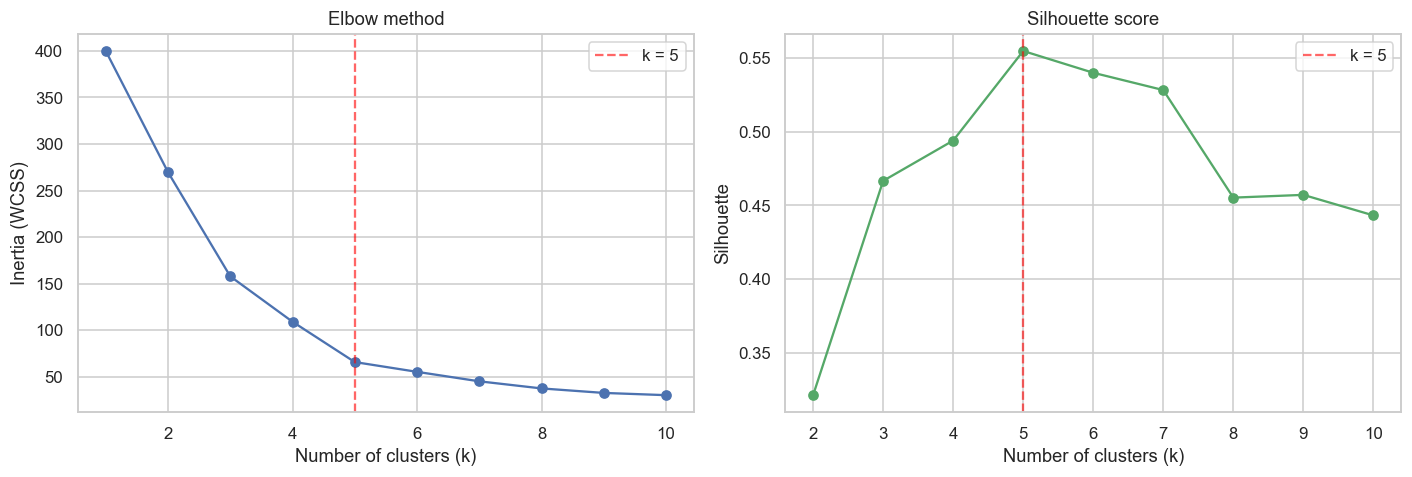

Best k by silhouette: 5


,k,inertia,silhouette
0,1,400.000,NaN
1,2,269.691,0.321
2,3,157.704,0.467
3,4,108.921,0.494
4,5,65.568,0.555
5,6,55.057,0.540
6,7,44.865,0.528
7,8,37.228,0.455
8,9,32.392,0.457
9,10,29.982,0.443


In [12]:
rows = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(X_scaled)
    sil = silhouette_score(X_scaled, km.labels_) if k > 1 else np.nan
    rows.append({'k': k, 'inertia': km.inertia_, 'silhouette': sil})

k_results = pd.DataFrame(rows)
best_k = int(k_results.loc[k_results['silhouette'].idxmax(), 'k'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(k_results['k'], k_results['inertia'], marker='o', color='#4C72B0')
axes[0].axvline(best_k, color='red', linestyle='--', alpha=0.6, label=f'k = {best_k}')
axes[0].set(title='Elbow method', xlabel='Number of clusters (k)', ylabel='Inertia (WCSS)')
axes[0].legend()

axes[1].plot(k_results['k'], k_results['silhouette'], marker='o', color='#55A868')
axes[1].axvline(best_k, color='red', linestyle='--', alpha=0.6, label=f'k = {best_k}')
axes[1].set(title='Silhouette score', xlabel='Number of clusters (k)', ylabel='Silhouette')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Best k by silhouette: {best_k}')
k_results.round(3)

## 6- Final Model 

In [13]:
K = best_k
kmeans = KMeans(n_clusters=K, n_init=10, random_state=SEED).fit(X_scaled)
df['Cluster'] = kmeans.labels_

print(f'K = {K} | Silhouette = {silhouette_score(X_scaled, kmeans.labels_):.3f}')
df['Cluster'].value_counts().sort_index().rename('Customers').to_frame()

K = 5 | Silhouette = 0.555


,Customers
Cluster,
0,81
1,39
2,22
3,35
4,23


### Is the result trustworthy?
Two quick checks:
1. **Stability** – re-running K-Means with different random initialisations should give the same grouping (Adjusted Rand Index = 1 means identical partitions).
2. **Other algorithms** – if Hierarchical clustering and a Gaussian Mixture find (almost) the same groups, the structure is real and not an artifact of K-Means.

In [14]:
base = kmeans.labels_

ari_seeds = [adjusted_rand_score(base, KMeans(K, n_init=10, random_state=s).fit_predict(X_scaled))
             for s in range(10)]
print(f'Stability across 10 seeds -> min ARI = {min(ari_seeds):.3f}\n')

alternatives = {
    'Agglomerative (ward)': AgglomerativeClustering(n_clusters=K).fit_predict(X_scaled),
    'Gaussian Mixture': GaussianMixture(n_components=K, random_state=SEED).fit_predict(X_scaled),
}

comparison = pd.DataFrame({
    'Algorithm': ['K-Means'] + list(alternatives),
    'Silhouette': [silhouette_score(X_scaled, base)] + [silhouette_score(X_scaled, l) for l in alternatives.values()],
    'ARI vs K-Means': [1.0] + [adjusted_rand_score(base, l) for l in alternatives.values()],
}).round(3)
comparison

Stability across 10 seeds -> min ARI = 1.000



,Algorithm,Silhouette,ARI vs K-Means
0,K-Means,0.555,1.000
1,Agglomerative (ward),0.554,0.942
2,Gaussian Mixture,0.554,0.956


## 7- Segment Profiling 

In [15]:
centroids = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=FEATURES)


def name_segment(income, spending):
    """Rule-based label from a centroid (income in k$, spending score 1-100)."""
    high_income, low_income = income >= 70, income <= 40
    high_spend, low_spend = spending >= 65, spending <= 35

    if high_income and high_spend:
        return 'Premium Spenders'
    if high_income and low_spend:
        return 'Frugal High-Earners'
    if low_income and high_spend:
        return 'Budget Enthusiasts'
    if low_income and low_spend:
        return 'Budget Savers'
    return 'Mainstream'


segment_names = {c: name_segment(*centroids.loc[c, FEATURES]) for c in centroids.index}
assert len(set(segment_names.values())) == K, 'Two clusters received the same name - review the rules'

df['Segment'] = df['Cluster'].map(segment_names)

centroids.assign(Segment=centroids.index.map(segment_names)).round(1)

,Income,Spending,Segment
0,55.3,49.5,Mainstream
1,86.5,82.1,Premium Spenders
2,25.7,79.4,Budget Enthusiasts
3,88.2,17.1,Frugal High-Earners
4,26.3,20.9,Budget Savers


In [16]:
profile = df.groupby('Segment').agg(
    Customers=('Segment', 'size'),
    Avg_Income=('Income', 'mean'),
    Avg_Spending=('Spending', 'mean'),
    Avg_Age=('Age', 'mean'),
    Male_Share=('Gender_Male', 'mean'),
)
profile['Share_of_customers_%'] = profile['Customers'] / len(df) * 100
profile['Male_Share'] = profile['Male_Share'] * 100
profile = profile.rename(columns={'Male_Share': 'Male_%'}).round(1).sort_values('Avg_Spending', ascending=False)
profile

,Customers,Avg_Income,Avg_Spending,Avg_Age,Male_%,Share_of_customers_%
Segment,,,,,,
Premium Spenders,39,86.5,82.1,32.7,46.2,19.5
Budget Enthusiasts,22,25.7,79.4,25.3,40.9,11.0
Mainstream,81,55.3,49.5,42.7,40.7,40.5
Budget Savers,23,26.3,20.9,45.2,39.1,11.5
Frugal High-Earners,35,88.2,17.1,41.1,54.3,17.5


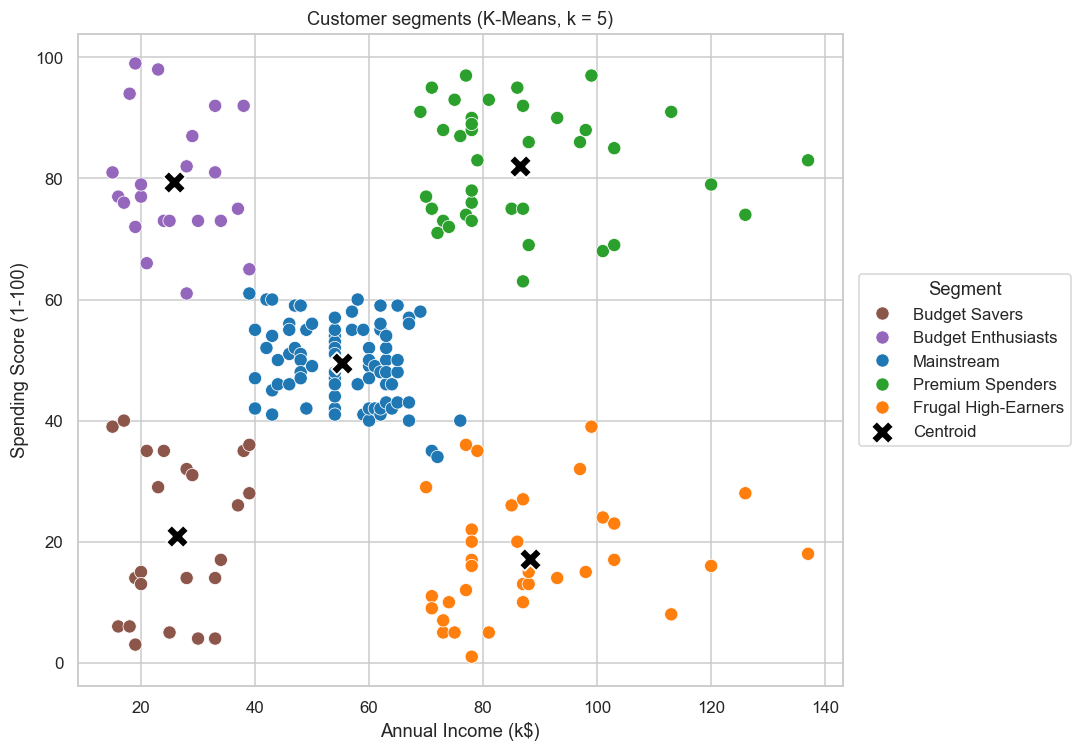

In [17]:
SEGMENT_COLORS = {
    'Premium Spenders': '#2CA02C',
    'Frugal High-Earners': '#FF7F0E',
    'Budget Enthusiasts': '#9467BD',
    'Budget Savers': '#8C564B',
    'Mainstream': '#1F77B4',
}

fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(data=df, x='Income', y='Spending', hue='Segment', palette=SEGMENT_COLORS,
                s=75, edgecolor='white', linewidth=0.5, ax=ax)
ax.scatter(centroids['Income'], centroids['Spending'], c='black', marker='X', s=220,
           edgecolor='white', linewidth=1.2, label='Centroid', zorder=5)
ax.set(title=f'Customer segments (K-Means, k = {K})',
       xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)')
ax.legend(title='Segment', loc='center left', bbox_to_anchor=(1.01, 0.5))
plt.tight_layout()
plt.show()

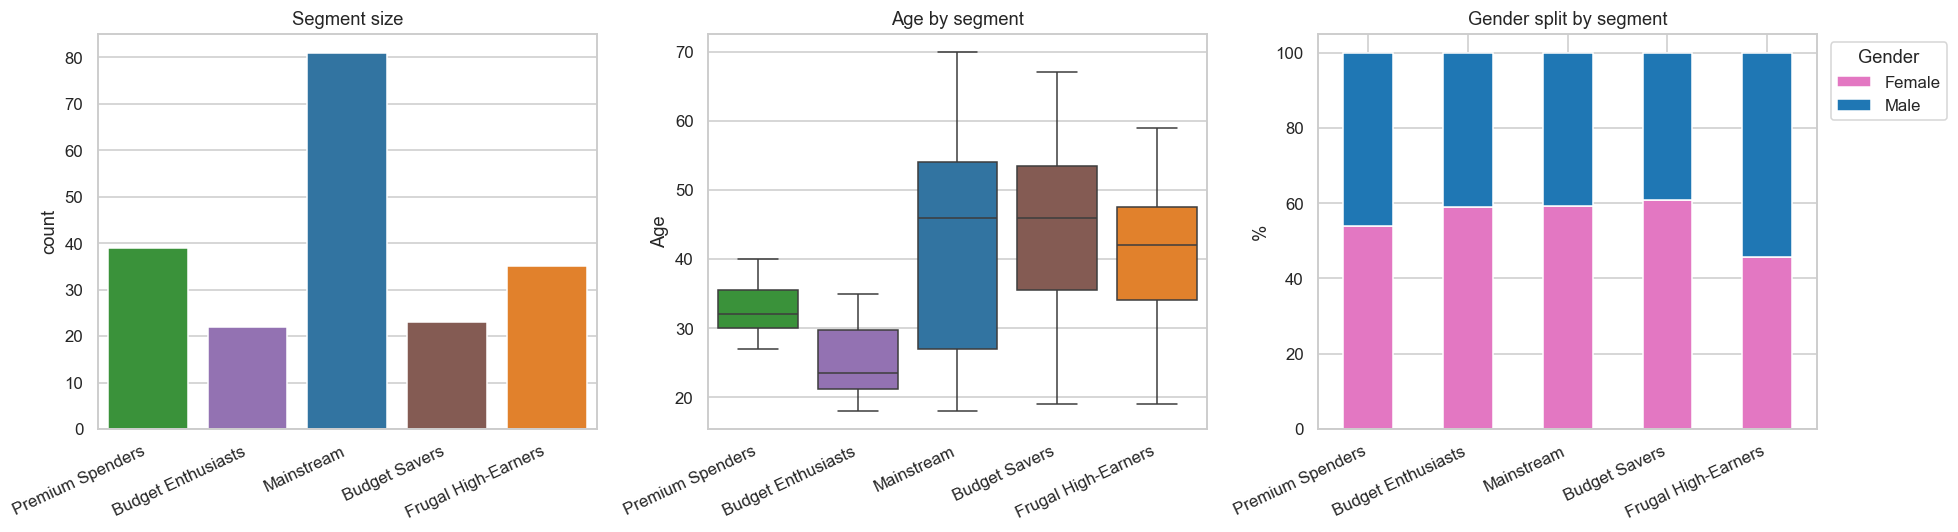

In [18]:
seg_order = profile.index.tolist()
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, x='Segment', order=seg_order, hue='Segment', palette=SEGMENT_COLORS, legend=False, ax=axes[0])
axes[0].set_title('Segment size')

sns.boxplot(data=df, x='Segment', y='Age', order=seg_order, hue='Segment', palette=SEGMENT_COLORS, legend=False, ax=axes[1])
axes[1].set_title('Age by segment')

gender_share = pd.crosstab(df['Segment'], df['Gender'], normalize='index').loc[seg_order] * 100
gender_share.plot(kind='bar', stacked=True, color=[GENDER_COLORS['Female'], GENDER_COLORS['Male']], ax=axes[2])
axes[2].set(title='Gender split by segment', ylabel='%')
axes[2].legend(title='Gender', loc='upper left', bbox_to_anchor=(1.01, 1))

for ax in axes:
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=25)
    plt.setp(ax.get_xticklabels(), ha='right')

plt.tight_layout()
plt.show()

## 8. Business interpretation

| Segment | Profile | Suggested action |
|---|---|---|
| **Premium Spenders** | High income, high spending (≈ 20% of customers) | VIP / loyalty programme, early access to new collections — the most valuable group to retain |
| **Frugal High-Earners** | High income, low spending (≈ 18%) | Big untapped potential: find out what they are missing (brands? experiences?) and run personalised offers |
| **Budget Enthusiasts** | Low income, high spending, the youngest group | Student/young-adult promotions, social-media campaigns, instalment-friendly offers |
| **Budget Savers** | Low income, low spending, the oldest group | Low priority for acquisition spend; discounts and clearance events work best |
| **Mainstream** | Middle income, middle spending (the largest group, ≈ 40%) | Broad campaigns, bundles and up-selling |

**Reading the profile charts**
- The male share stays between roughly 40% and 55% in every segment (44% overall), which matches the EDA: **income and spending behaviour, not gender, define the segments.**
- Age *does* tell the segments apart: Premium Spenders are concentrated between about 27 and 40 years old, Budget Enthusiasts are the youngest (average ≈ 25), and Budget Savers are the oldest (average ≈ 45).

## 9- Save The Model 

In [19]:
model = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=K, n_init=10, random_state=SEED)),
]).fit(df[FEATURES])

# The pipeline must reproduce exactly the same clusters as the step-by-step version above.
assert (model.predict(df[FEATURES]) == df['Cluster']).all()

MODEL_PATH = 'customer_segmentation.joblib'
joblib.dump({'model': model, 'features': FEATURES, 'segment_names': segment_names}, MODEL_PATH)
print(f'Saved -> {MODEL_PATH}')

Saved -> customer_segmentation.joblib


## 10- Predict the segment of new customers 

In [20]:
def predict_segment(income, spending, path=MODEL_PATH):
    """Return the segment name for a customer. income in k$, spending score in 1-100."""
    if income < 0:
        raise ValueError('Income must be a non-negative number (in k$).')
    if not 1 <= spending <= 100:
        raise ValueError('Spending score must be between 1 and 100.')

    bundle = joblib.load(path)
    X_new = pd.DataFrame([[income, spending]], columns=bundle['features'])
    cluster = int(bundle['model'].predict(X_new)[0])
    return bundle['segment_names'][cluster]


examples = [(15, 95), (90, 15), (60, 50), (95, 85), (20, 10)]
for income, spending in examples:
    print(f'Income = {income:>3}k$, Spending = {spending:>3}  ->  {predict_segment(income, spending)}')

Income =  15k$, Spending =  95  ->  Budget Enthusiasts
Income =  90k$, Spending =  15  ->  Frugal High-Earners
Income =  60k$, Spending =  50  ->  Mainstream
Income =  95k$, Spending =  85  ->  Premium Spenders
Income =  20k$, Spending =  10  ->  Budget Savers


In [21]:
bundle = joblib.load(MODEL_PATH)

new_customers = pd.DataFrame({'Income': [20, 90, 60, 95], 'Spending': [90, 15, 50, 85]})
clusters = bundle['model'].predict(new_customers[bundle['features']])
new_customers['Segment'] = [bundle['segment_names'][c] for c in clusters]
new_customers

,Income,Spending,Segment
0,20,90,Budget Enthusiasts
1,90,15,Frugal High-Earners
2,60,50,Mainstream
3,95,85,Premium Spenders


## 11. Conclusions & limitations

**Conclusions**
- The customers form **5 clear segments** based on income and spending score. Elbow and silhouette agree on k = 5, the result is stable across random seeds, and two other algorithms find nearly the same groups.
- The most actionable segments are *Premium Spenders* (protect them) and *Frugal High-Earners* (the biggest growth opportunity).

**Limitations**
- Only 200 customers, and the spending score is a single score assigned by the mall — a real project would use actual transaction history (recency, frequency, monetary value).
- Segments are based on two variables only; age is used to *describe* segments, not to build them.
- Silhouette scores measure geometric separation, not business value — the segments should still be validated with the marketing team.

**Possible next steps**
- Add behavioural features (purchase frequency, basket size, categories) and try 3-D clustering with `Age`.
- Track how customers move between segments over time.
- Wrap `predict_segment` in a small Streamlit / Flask app.